# Chosen Model Analysis

This notebook requires completed, current artifacts from `Models_Pipeline.ipynb`. It does not train or reselect a model. `HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50` is fixed as the final specification because its pre-specified equal-weight combination of the standalone `LGBM_40` and `DEEPSET_40_DYNAMIC` OOS forecasts produced the strongest balance of statistical and economic performance. The analysis compares it with both standalone components and the validation-weighted dynamic hybrid.

The chosen strategy applies fixed 50/50 weights and estimates no additional combination parameter. Regimes use trailing 12-month market volatility and a one-month-lagged expanding historical median threshold. Component importance is reported separately for the standalone LightGBM and dynamic DeepSets models. Factor attribution uses FF5 plus momentum with Newey--West-6 inference. Economic robustness includes long/short attribution, transaction costs, universe and weighting sensitivity, missing-return stress, and observed-return outlier checks.

In [1]:
from pathlib import Path
import os
import sys
import importlib

COLAB_PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FDS Project')
WINDOWS_PROJECT_DIR = Path('C:/Users/sandh/OneDrive/Documents/Coding/FDS Project')
if Path('/content').exists() and not COLAB_PROJECT_DIR.exists():
    from google.colab import drive
    drive.mount('/content/drive')
PROJECT_DIR = COLAB_PROJECT_DIR if COLAB_PROJECT_DIR.exists() else WINDOWS_PROJECT_DIR
os.chdir(PROJECT_DIR)
project_path = str(PROJECT_DIR)
sys.path = [path for path in sys.path if path != project_path]
sys.path.insert(0, project_path)
for module_name in tuple(sys.modules):
    if module_name == 'src' or module_name.startswith('src.'):
        del sys.modules[module_name]
importlib.invalidate_caches()
print('Project directory:', PROJECT_DIR)

Project directory: /content/drive/MyDrive/Colab Notebooks/FDS Project


In [2]:
from src.config import ExperimentConfig

CHOSEN_MODEL_ID = 'HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50'
TRAINED_HYBRID_ID = 'HYBRID_LGBM40_DEEPSET40_DYNAMIC'
DATA_PATH = PROJECT_DIR / 'jkp_USA_100chars_1980_2024.parquet'
OUTPUT_DIR = PROJECT_DIR / 'model_runs'
CONFIG = ExperimentConfig(
    experiment_id='core20_benchmarks_v1',
    project_dir=PROJECT_DIR, data_path=DATA_PATH, output_dir=OUTPUT_DIR,
    selected_models=(TRAINED_HYBRID_ID,), seed=42, use_gpu=False,
)
CONFIG.validate()

# Build the deterministic comparator and load or refresh its diagnostics.
from src.developed_markets import build_fifty_fifty_comparator
fifty_fifty_metrics = build_fifty_fifty_comparator(CONFIG)

from src.portfolio_robustness import run_portfolio_robustness
chosen_robustness = run_portfolio_robustness(
    CONFIG.run_dir, model_ids=(CHOSEN_MODEL_ID,)
)

from src.chosen_model_analysis import validate_chosen_model_artifacts
chosen_artifacts = validate_chosen_model_artifacts(CONFIG, CHOSEN_MODEL_ID)

# Validate the fixed chosen-model entry against the completed comparison.
import pandas as pd
comparison = pd.read_csv(CONFIG.run_dir / 'model_comparison.csv')
comparison = pd.concat([comparison, pd.DataFrame([fifty_fifty_metrics])], ignore_index=True, sort=False)
chosen_row = comparison.loc[comparison['model_id'].eq(CHOSEN_MODEL_ID)]
if len(chosen_row) != 1:
    raise RuntimeError(f'Expected exactly one comparison row for {CHOSEN_MODEL_ID}.')
best_sharpe_model = comparison.loc[comparison['sharpe'].idxmax(), 'model_id']
print('Chosen model:', CHOSEN_MODEL_ID)
print('Model signature:', chosen_artifacts['model_signature'])
print('Selection rule: fixed 50/50 average of standalone LGBM40 and dynamic DeepSets OOS forecasts')
print('Highest realized Sharpe model:', best_sharpe_model)
print('Run directory:', CONFIG.run_dir)
display(chosen_row[[
    'model_id', 'pooled_oos_r2', 'robust_oos_r2', 'mean_monthly_rank_ic',
    'annualized_return', 'annualized_volatility', 'sharpe',
    'newey_west_t_stat', 'max_drawdown', 'hit_rate', 'n_months',
]])

HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50: current robustness; skipping
Chosen model: HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
Model signature: d14e8c2a63ec5c8e
Selection rule: fixed 50/50 average of standalone LGBM40 and dynamic DeepSets OOS forecasts
Highest realized Sharpe model: HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
Run directory: /content/drive/MyDrive/Colab Notebooks/FDS Project/model_runs/core20_benchmarks_v1


,model_id,pooled_oos_r2,robust_oos_r2,mean_monthly_rank_ic,annualized_return,annualized_volatility,sharpe,newey_west_t_stat,max_drawdown,hit_rate,n_months
19,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50,0.003475,0.00403,0.060747,0.34134,0.168209,2.029261,6.382897,-0.35137,0.766026,312


## 1. Signal-date market regimes

In [3]:
from src.chosen_model_analysis import build_signal_date_regimes, regime_stability

regimes = build_signal_date_regimes(CONFIG)
regime_results = regime_stability(CONFIG, CHOSEN_MODEL_ID, regimes)
display(regime_results)

,model_id,regime,mean_monthly_return,annualized_return,annualized_volatility,sharpe,t_stat,newey_west_t_stat,max_drawdown,hit_rate,n_months,mean_rank_ic,rank_ic_newey_west_t_stat,rank_ic_positive_rate,mean_trailing_market_vol
0,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50,HIGH_VOL,0.035614,0.427374,0.201564,2.120292,8.073832,4.802063,-0.325117,0.752874,174,0.069512,7.448106,0.770115,0.056332
1,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50,LOW_VOL,0.019405,0.232862,0.105617,2.204776,7.476758,8.182562,-0.063740,0.782609,138,0.049696,10.343820,0.833333,0.027440


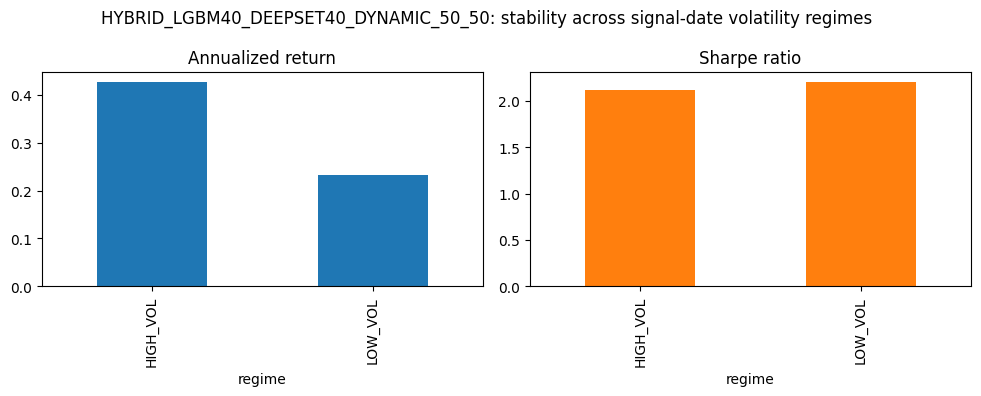

In [4]:
import matplotlib.pyplot as plt
regime_results.set_index('regime')[['annualized_return', 'sharpe']].plot.bar(
    subplots=True, layout=(1, 2), figsize=(10, 4), legend=False,
    title=['Annualized return', 'Sharpe ratio']
)
plt.suptitle(f'{CHOSEN_MODEL_ID}: stability across signal-date volatility regimes')
plt.tight_layout(); plt.show()

## 2. Incremental value of the fixed 50/50 combination

The chosen 50/50 forecast is compared with the standalone `LGBM_40` and `DEEPSET_40_DYNAMIC` forecasts and with the validation-weighted dynamic hybrid. Paired inference uses monthly Newey--West tests, test-year-clustered rank-IC tests, year-block bootstrap Sharpe intervals, and Holm-adjusted p-values.

In [5]:
from src.chosen_model_analysis import standalone_fifty_fifty_component_analysis

aligned_tests, annual_consistency, aligned_monthly = standalone_fifty_fifty_component_analysis(
    CONFIG, regimes=regimes, bootstrap_draws=2000
)
display(aligned_tests)
display(annual_consistency)

,model_a,model_b,mean_monthly_mse_difference,mse_difference_nw_t_stat,mse_difference_p_value,mean_monthly_return_difference,return_difference_nw_t_stat,return_difference_p_value,mean_rank_ic_difference,rank_ic_difference_clustered_t_stat,...,sharpe_difference,sharpe_difference_bootstrap_standard_error,sharpe_difference_exceeds_one_standard_error,sharpe_difference_block_bootstrap_ci_low,sharpe_difference_block_bootstrap_ci_high,simpler_model_within_sharpe_interval,n_paired_months,mse_difference_holm_p_value,return_difference_holm_p_value,rank_ic_difference_holm_p_value
0,FIFTY_FIFTY,LGBM_40,-0.000012,-0.285836,0.775004,0.003943,2.279939,0.022611,0.006888,2.128017,...,0.361819,0.191660,True,0.051313,0.802605,False,312,0.775004,0.067834,0.100007
1,FIFTY_FIFTY,DEEPSET_40_DYNAMIC,-0.000146,-2.806175,0.005013,0.002385,2.122405,0.033804,0.003114,1.039586,...,0.105836,0.091823,True,-0.060315,0.299623,True,312,0.015040,0.067834,0.372215
2,FIFTY_FIFTY,VALIDATION_WEIGHTED,-0.000065,-1.868317,0.061718,0.002383,1.527190,0.126714,0.003596,1.322182,...,0.190801,0.172234,True,-0.085421,0.589725,True,312,0.123436,0.126714,0.372215


forecast,test_year,DEEPSET_40_DYNAMIC,FIFTY_FIFTY,LGBM_40,VALIDATION_WEIGHTED,FIFTY_FIFTY_MINUS_LGBM_40,FIFTY_FIFTY_MINUS_DEEPSET_40_DYNAMIC,FIFTY_FIFTY_MINUS_VALIDATION_WEIGHTED
0,1999,0.577009,0.396485,-0.081985,-0.055729,0.478470,-0.180524,0.452214
1,2000,1.448000,1.604102,1.383936,1.545603,0.220166,0.156102,0.058500
2,2001,0.879346,1.089553,1.077241,1.155684,0.012311,0.210206,-0.066131
3,2002,0.749415,0.751372,0.635013,0.712239,0.116359,0.001957,0.039133
4,2003,-0.027525,0.069434,0.083621,-0.027525,-0.014187,0.096960,0.096960
5,2004,0.261049,0.147115,0.026331,0.057063,0.120784,-0.113934,0.090051
6,2005,0.292875,0.284071,0.243551,0.262278,0.040520,-0.008803,0.021793
7,2006,0.204342,0.232261,0.208420,0.223376,0.023841,0.027918,0.008885
8,2007,0.134153,0.168505,0.216518,0.194291,-0.048013,0.034352,-0.025786
9,2008,0.509582,0.552545,0.490140,0.568965,0.062405,0.042964,-0.016420


In [6]:
fixed_weights = pd.DataFrame([{
    'model_id': CHOSEN_MODEL_ID,
    'component': 'LGBM_40', 'weight': 0.5,
}, {
    'model_id': CHOSEN_MODEL_ID,
    'component': 'DEEPSET_40_DYNAMIC', 'weight': 0.5,
}])
display(fixed_weights)

,model_id,component,weight
0,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50,LGBM_40,0.5
1,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50,DEEPSET_40_DYNAMIC,0.5


## 4. Hybrid component importance by regime

Because the chosen model has no fitted ensemble checkpoint, importance is measured separately for its standalone components. LightGBM importance uses absolute tree contributions within each regime. Dynamic DeepSets importance groups each characteristic's current, lagged, and velocity coordinates and permutes that group across firms within each month. The two scales are not presented as a single ensemble-wide ranking.

In [7]:
from src.chosen_model_analysis import hybrid_component_feature_importance_by_regime

importance = hybrid_component_feature_importance_by_regime(CONFIG, CHOSEN_MODEL_ID, regimes)
top_importance = importance.query('importance_rank <= 10')
display(top_importance)

,model_id,regime,feature,mean_abs_contribution,importance_share,importance_rank,importance_method,permutation_mse_increase,relative_mse_increase,n_stock_observations,n_months,positive_importance,component_model_id,hybrid_model_id
0,LGBM_40,HIGH_VOL,ret_12_1,0.001992,0.094939,1,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
1,LGBM_40,HIGH_VOL,f_score,0.001850,0.088194,2,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
2,LGBM_40,HIGH_VOL,rd_me,0.001379,0.065715,3,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
3,LGBM_40,HIGH_VOL,ocf_me,0.001094,0.052150,4,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
4,LGBM_40,HIGH_VOL,ret_1_0,0.001087,0.051827,5,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
5,LGBM_40,HIGH_VOL,niq_at,0.000953,0.045438,6,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
6,LGBM_40,HIGH_VOL,rmax5_21d,0.000936,0.044598,7,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
7,LGBM_40,HIGH_VOL,prc_highprc_252d,0.000835,0.039821,8,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
8,LGBM_40,HIGH_VOL,debt_me,0.000743,0.035398,9,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50
9,LGBM_40,HIGH_VOL,op_at,0.000666,0.031748,10,mean_absolute_tree_contribution,NaN,NaN,NaN,NaN,NaN,LGBM_40,HYBRID_LGBM40_DEEPSET40_DYNAMIC_50_50


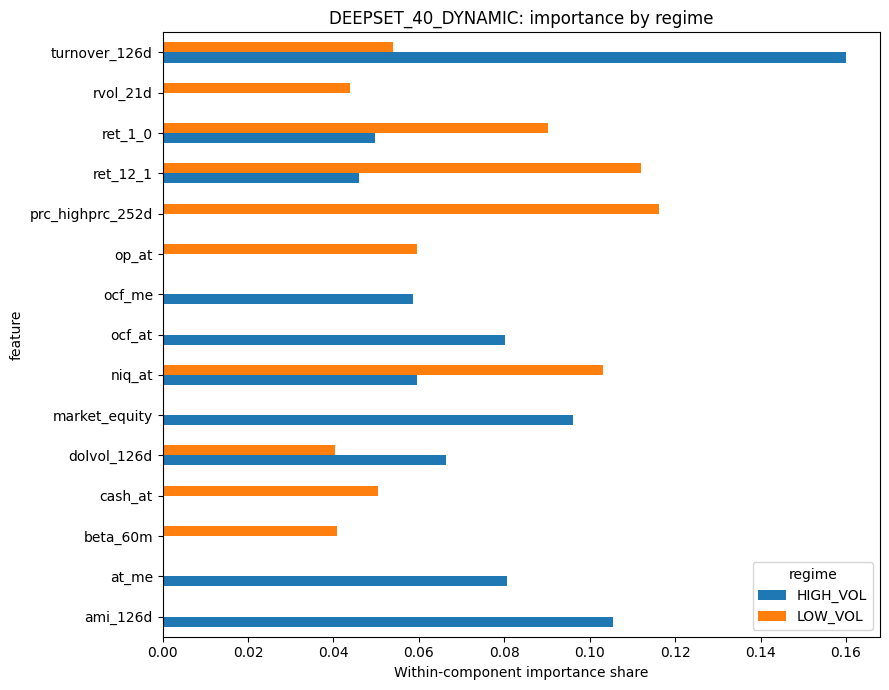

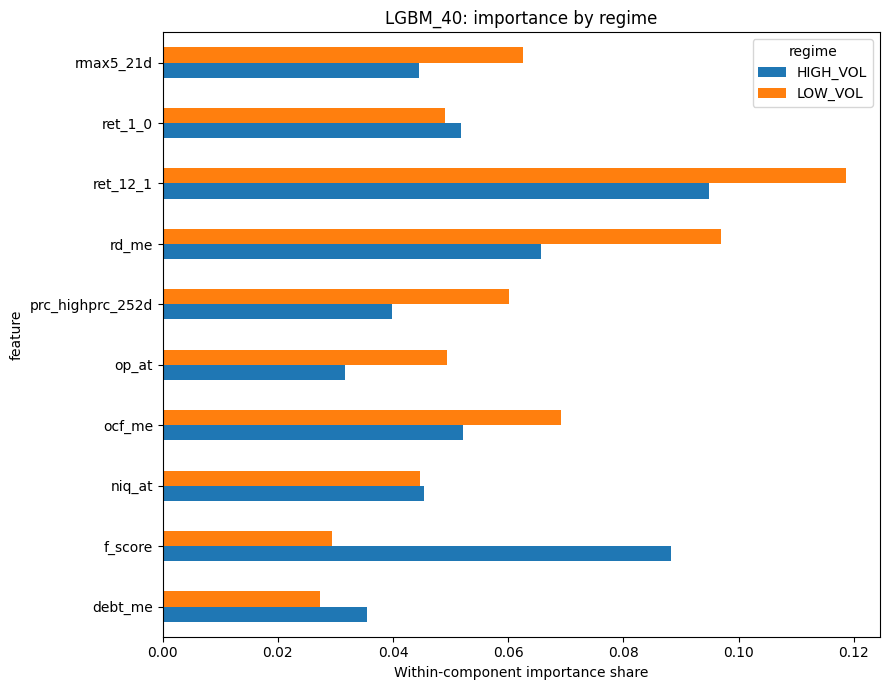

In [8]:
for component_id, component in top_importance.groupby('component_model_id'):
    pivot = component.pivot(index='feature', columns='regime', values='importance_share').fillna(0)
    pivot.plot.barh(figsize=(9, 7), title=f'{component_id}: importance by regime')
    plt.xlabel('Within-component importance share'); plt.tight_layout(); plt.show()

## 5. FF5 plus momentum factor decomposition

Monthly US FF5 and momentum factors are downloaded from Kenneth French's data library for ex-post return attribution. These data do not enter model fitting, validation, or portfolio formation.

In [9]:
from src.chosen_model_analysis import download_ff5_momentum, factor_decomposition

factors = download_ff5_momentum()
factor_results = factor_decomposition(CONFIG, CHOSEN_MODEL_ID, factors)
display(factor_results)

,coefficient,monthly_estimate,hac_standard_error,hac_t_stat,annualized_estimate
0,alpha,0.026625,0.003556,7.487918,0.319504
1,mkt_rf,-0.177648,0.062954,-2.821888,-0.177648
2,smb,0.015565,0.113077,0.137653,0.015565
3,hml,0.228337,0.112828,2.023762,0.228337
4,rmw,0.594768,0.128317,4.635140,0.594768
5,cma,0.172814,0.193990,0.890837,0.172814
6,mom,0.063185,0.106294,0.594439,0.063185


## 6. Long-versus-short attribution and final cost discussion

In [10]:
from IPython.display import Markdown, display
from src.chosen_model_analysis import long_short_and_cost_attribution

attribution, cost_discussion = long_short_and_cost_attribution(CONFIG, CHOSEN_MODEL_ID)
display(attribution)
display(Markdown(cost_discussion))

,component,mean_monthly_contribution,annualized_contribution
0,long_leg,0.017175,0.206101
1,short_leg,0.011270,0.135239
2,long_short,0.028445,0.341340


The full-universe equal-weight 10% portfolio turns over 1.031 per month. Its gross annualized return is 34.13%; the 25 bps scenario produces 31.04% with a Sharpe of 1.85. The simple proportional-cost break-even estimate is 275.9 bps per unit of turnover. These scenarios exclude stock-borrow fees, bid-ask heterogeneity and nonlinear market impact, so they are sensitivity analysis rather than a claim of fully implementable net performance. Within the full/equal portfolio, annualized returns are 35.48% after monthly 0.5/99.5 percentile winsorization, 35.29% after monthly 1/99 percentile winsorization, and 34.29% after excluding realized absolute returns above 1,000%. At 25 bps, the robustness matrix is: EX_MICRO/EQUAL: 25 bps annualized return 15.61%, Sharpe 0.79; EX_MICRO/VALUE: 25 bps annualized return 11.34%, Sharpe 0.54; FULL/EQUAL: 25 bps annualized return 31.04%, Sharpe 1.85; FULL/VALUE: 25 bps annualized return 17.12%, Sharpe 0.76.

## 7. Final audit, frozen manifest, and report-ready outputs

This step validates model coverage, prediction schemas, signatures, diagnostics, target timing, portfolio reconstruction, robustness outputs, and declared comparisons. It then writes the frozen research manifest and report-ready tables and figures without modifying model predictions.

In [ ]:
from src.project_finalization import (
    run_final_project_audit, write_frozen_manifest, generate_report_outputs,
)

FINAL_MODEL_IDS = (
    'LASSO_20', 'LGBM_20', 'XGBOOST_20', 'NN2_20', 'NN3_20', 'NN4_20',
    'LGBM_40', 'LGBM_60', 'LGBM_80', 'LGBM_100',
    'LGBM_40_LAG1', 'LGBM_40_LAG2',
    'MLP_40', 'DEEPSET_40',
    'DEEPSET_40_LAG1', 'DEEPSET_40_DYNAMIC',
    'HYBRID_MLP40_DEEPSET40',
    'HYBRID_LGBM40_DEEPSET40',
    'HYBRID_LGBM40_DEEPSET40_DYNAMIC',
)
final_audit = run_final_project_audit(CONFIG, FINAL_MODEL_IDS, CHOSEN_MODEL_ID)
display(final_audit.loc[~final_audit['passed']])
if not final_audit['passed'].all():
    raise RuntimeError('Final project audit has failed checks; review the table above.')
frozen_manifest = write_frozen_manifest(CONFIG, FINAL_MODEL_IDS, CHOSEN_MODEL_ID)
report_files = generate_report_outputs(CONFIG, CHOSEN_MODEL_ID)
print('Final audit passed:', len(final_audit), 'checks')
print('Frozen chosen model:', frozen_manifest['chosen_model_id'])
display(pd.DataFrame({'report_file': list(report_files)}))

## Interpretation checklist

- Does performance and rank IC remain positive in both volatility regimes?
- Do the leading grouped permutation-importance characteristics remain economically interpretable across regimes?
- Is FF5+momentum alpha positive with a reliable HAC t-stat?
- Is performance balanced across the long and short legs?
- Does the strategy remain attractive under the 25 bps scenario, outside microcaps, and under the adverse missing-return stress?
- State explicitly that model selection preceded this analysis; these results explain and stress-test the chosen model rather than reopen the model search.